# Delivery Lead-Time Regression

**IT5006 · Phase 2**

**Modelling question:** at order placement, how many fractional days will an order take to reach its customer, and can a learned model improve on the quoted delivery promise and simpler regression baselines?

Phase 1 established that delivery duration was related to distance, the quoted promise, freight and purchase timing. This notebook develops that candidate into a prediction task: it defines the eligible orders and purchase-time inputs, compares linear and tree model families, examines feature and parameter changes, and evaluates the retained model. The target remains purchase-to-receipt duration, not days late relative to the promise.

## Problem Scoping Checklist

| Course check | Assessment for delivery lead-time regression |
|---|---|
| **Derivable target** | Purchase and receipt timestamps directly define fractional duration; no external labels are needed. |
| **Realistic features** | Order, location, quote and archived product/seller inputs only. Post-purchase outcomes are excluded; attribute availability is an assumption. |
| **Sufficient signal** | Phase 1 associations motivate candidate inputs; Phase 2 compares fitted predictions with shared-protocol references. |
| **Manageable imbalance/skew** | Retain valid long durations, compare loss/target representations within training, and report MAE, RMSE and tail errors. No classification resampling of the regression target. |
| **Clear stakeholder** | Customer-service and fulfilment teams can use an estimate for expectation communication and human follow-up. |

## Context & Methods

The primary sample contains **96,470 completed deliveries** from the course archive, with one row per order. Phase 1 found a right-skewed duration distribution: median **10.22 days**, mean **12.56**, P90 **23.10**, with **306** orders above 60 days. The same target definition and valid extremes are preserved in modelling.

- **Prediction point:** order placement. Inputs describe what is assumed available then; the receipt timestamp is used only to construct y.
- **Main comparison:** linear and tree baselines, their variants, and a later HGB/stacking comparison under one random-order protocol.
- **Selection:** five-fold training CV MAE. Test scores describe frozen comparisons, rather than define the objective or choose this stage's parameter winner.
- **Evaluation:** errors are in days. RMSE, signed bias, ±3-day coverage and outcome/route slices supplement the average error.
- **Reproducibility:** exact preparation and split manifests are checked; source data, order-level predictions and models remain local. Published tables and plots contain aggregate results.

Archived input availability, completed-delivery coverage and repeated development exposure qualify the interpretation. They are discussed with the relevant results and in the final limitations.

### Execution and source

The input is the unchanged course Olist ZIP, supplied through `OLIST_ARCHIVE`. The default `review` run rebuilds the data and partitions when the ZIP is supplied, then displays and checks the saved results of fitted experiments. Without the ZIP, it uses labelled aggregate preparation evidence. `RUN_MODE="reproduce"` refits the fixed model specifications; `WITH_CV=True` also repeats their five-fold evaluation.

The search and latest stacking results are retained from their completed experiments, rather than rerun by default. Fitting code is in the supplied `src/` and `scripts/` modules; the [README](../README.md) gives the reproduction commands. This separation keeps expensive fitting and the submission narrative on the same recorded inputs and configurations.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image

ROOT = next(candidate for parent in [Path.cwd(), *Path.cwd().parents]
            for candidate in [parent, parent / "delivery_regression_best",
                              parent / "Regression/delivery_regression_best",
                              parent / "Phase 2/Regression/delivery_regression_best"]
            if (candidate / "config/report_models.json").is_file())
for folder in [ROOT / "src", ROOT / "scripts"]:
    sys.path.insert(0, str(folder))
from integrated_notebook_support import start, audit_sources, prepare_orders, refit_models, finish

RUN_MODE = "review"
WITH_CV = False
context = start(ROOT, RUN_MODE, WITH_CV)
RESULTS = ROOT / "results/report_supplement"
TABLES = RESULTS / "tables"
pd.set_option("display.max_columns", 10)
print("Model execution:", "reconstruction requested" if RUN_MODE == "reproduce" else "saved fitted experiments")
print("Source data:", "course ZIP" if context["archive"] else "published aggregate audit")

Model execution: saved fitted experiments
Source data: course ZIP


## 1. Prepare the order-level modelling sample

### 1.1 Source tables and join checks

Seven course tables supply the inputs: orders, customers, items, sellers, products, geography and category translation. Orders link to customers; item rows link to sellers and products. Payments and reviews are not predictors for this purchase-time task.

Joins are checked as `many_to_one` or `one_to_one` where appropriate. Items are aggregated before modelling so that an order with several items does not receive extra weight. Duplicate geographic postal prefixes are expected reference observations, rather than duplicate order keys. The checks below cover keys, foreign-key relationships, missing fields, statuses, timestamp parsing and value ranges. They follow the course data-contract approach using pandas, without claiming to run the Great Expectations library.

In [2]:
source_tables, quality_checks = audit_sources(context)
display(source_tables[["table", "rows"]])

# Show source exceptions; full check results are retained in the supporting CSV.
exceptions = quality_checks.loc[quality_checks.unexpected_rows.gt(0)]
display(exceptions[["check", "unexpected_rows", "action"]])

,table,rows
0,orders,99441
1,items,112650
2,customers,99441
3,sellers,3095
4,products,32951
5,geo,1000163
6,translation,71


,check,unexpected_rows,action
15,Delivered receipt timestamp observable,8,"Exclude the 8 unobservable targets, not all mi..."
17,Coordinates inside conservative Brazil envelope,29,"Screen these 29 coordinate rows, deduplicate p..."
18,Product weight observable and positive,6,Keep orders; mark incomplete weight and fit im...


### 1.2 Target definition, exclusions and missingness

For each completed delivery, define **lead time = `(receipt timestamp − purchase timestamp).total_seconds() / 86400`**. This preserves fractions of a day; timestamps are used as supplied, without adding a timezone conversion. Only delivered orders with a valid, non-negative duration enter the target population. A missing target cannot be imputed as if the delivery had been observed.

The Phase 2 geographic preparation screens coordinates to latitude [−35, 6] and longitude [−75, −25], removes duplicate coordinate pairs, and uses postal-prefix medians. This reduces the influence of implausible coordinates and heavily repeated reference points. The label `V2` here refers to this preparation revision; it is not a newer external dataset or the Phase 1 consolidated table's version label.

Missing predictor values remain eligible. Distance is the maximum **observed** seller–customer great-circle distance, not a road route. An order is cross-state if any seller is outside the customer's state. Imputation is learned from training data; missingness flags preserve information about incomplete measurements.

In [3]:
train, test = prepare_orders(context)
display(pd.read_csv(TABLES / "regression_cohort_flow.csv"))

if train is not None:
    # Verify one row per order after aggregation and the unchanged target population.
    assert len(train) + len(test) == 96470
    assert train.order_id.is_unique and test.order_id.is_unique
    assert set(train.order_id).isdisjoint(test.order_id)
    assert train.lead_time_days.ge(0).all() and test.lead_time_days.ge(0).all()

,step,n
0,Source orders,99441
1,Orders marked delivered,96478
2,Delivered missing receipt (excluded),8
3,Eligible completed orders with valid target an...,96470
4,Negative target durations among remaining orders,0
5,Eligible orders missing item records,0
6,Retained valid targets above 60 days,306
7,Missing maximum distance (retained),477
8,Missing average product weight (retained),22


**Finding.** The source contains 96,478 delivered orders; eight have no receipt timestamp and cannot provide y. The modelling sample therefore contains **96,470** valid completed deliveries, including **306** above 60 days. No upper-duration cutoff is imposed.

The source checks flag **29 geographic rows** outside the screen and **six product records** with missing/non-positive weight. After joins and order aggregation, **477 orders** lack maximum distance and **22** lack complete average weight. These are different grains, not counts to add together. Missing predictors do not remove otherwise valid targets. Zero freight is allowed.

**Modelling implication.** The cohort measures delivery duration conditional on completion; it cannot establish performance on orders that are cancelled or still unresolved. Geography is a proxy, and incomplete measurements need fold-fitted handling rather than target-based exclusions.

## 2. Define the inputs and evaluation protocol

### 2.1 What can be known at purchase?

The baseline package **F0** contains 16 purchase attributes: distance and missingness, promise duration, price/freight, item and seller counts, product weight, customer state, route/category and purchase calendar. **F1** adds six cyclic calendar terms, three promise/distance/cross-state interactions and one state-route category. Cyclic terms keep adjacent hours or weekdays close across a calendar boundary; interactions allow the effect of a promise or distance to vary by route.

The expanded purchase package adds primary seller identity, finer geographic routes and product composition. The primary seller and dominant category are selected by the largest summed item price, with deterministic ID/name tie-breaking; counts and shares still account for all items. Order/customer IDs remain join and audit keys, while seller identity is deliberately treated as categorical information.

Actual delivery, carrier handover, final status, reviews and outcome-derived lateness are excluded from X. The archive has no complete revision history for the quote, seller and product attributes, so their availability at purchase is an explicit assumption.

In [4]:
feature_groups = pd.DataFrame({
    "Feature set": ["F0", "F1", "Expanded purchase", "Time", "Risk"],
    "Added information": ["16 original purchase attributes", "Calendar cycles and interactions",
                          "Seller, route and product composition", "Absolute date and year-month",
                          "Predicted probability of delivery exceeding 30 days"]})
display(feature_groups)
# Individual field definitions are in final_feature_catalogue.csv.
feature_catalogue = pd.read_csv(TABLES / "final_feature_catalogue.csv")

,Feature set,Added information
0,F0,16 original purchase attributes
1,F1,Calendar cycles and interactions
2,Expanded purchase,"Seller, route and product composition"
3,Time,Absolute date and year-month
4,Risk,Predicted probability of delivery exceeding 30...


### 2.2 Random split and training-only preprocessing

The 96,470 eligible orders are split **67/33** into **64,634 training / 31,836 test orders**, using seed **33**. Five shuffled folds within training (seed 33) select variants and settings. Each fold fits on four parts and scores the remaining part; there is no separate validation set. The 67/33 ratio is adapted from Zaghloul et al. (2024), while the seed and fold count are project choices.

Phase 1 proposed a later-period holdout. The Phase 2 team adopted random splitting for a common historical-comparison protocol. This changes the evaluation question: the scores describe new held-out orders from the same historical mixture, rather than performance in a future period. Historical time-split experiments are kept separately.

Numeric medians, categorical fill values, scaling, rare-category rules and encoding vocabularies are fitted inside each training partition. The basic F0/F1 pipeline uses one-hot encoding with a rare-category threshold of 20; the expanded purchase encoder uses 30. Test values do not determine these rules. Predictions are assessed in original days, with negative predictions floored at zero.

In [5]:
display(pd.read_csv(TABLES / "split_population.csv"))
comparison = pd.read_csv(TABLES / "train_cv_test_comparison.csv")

# CV statistics use equal weighting of the five validation folds.
# SD below uses ddof=0, consistent with sklearn's std_test_score.
def model_scores(names, include_test=False):
    columns = ["model", "Train_MAE_days", "CV_MAE_mean_days", "CV_MAE_SD_population_days"]
    if include_test:
        columns += ["Test_MAE_days", "Test_RMSE_days", "Test_R2"]
    return comparison.set_index("model").loc[names].reset_index()[columns].rename(columns={
        "model": "Model", "Train_MAE_days": "Train MAE", "CV_MAE_mean_days": "CV MAE",
        "CV_MAE_SD_population_days": "CV SD", "Test_MAE_days": "Test MAE",
        "Test_RMSE_days": "Test RMSE", "Test_R2": "Test R²"}).round(4)

,split,n,purchase_min,purchase_max,mean_days,median_days,above_30_days_n,above_60_days_n,chronology_flag_n
0,train,64634,2016-09-15 12:16:38,2018-08-29 15:00:37,12.584779,10.216574,3086,207,59
1,test,31836,2016-10-03 16:56:50,2018-08-29 14:18:28,12.504290,10.219039,1464,99,25


### 2.3 Why the risk feature needs cross-fitting

The candidate `risk_p30` is a predicted probability of duration exceeding 30 days. It summarises purchase-time X through an auxiliary classifier, rather than reveal whether the current order actually becomes slow. If a classifier trained on an order's label produced that same order's regression input, its fitted probability could transmit the label into the regressor.

Within each outer regression fold, **three inner folds** generate held-out risk values for the fitting orders. A classifier fitted on the complete outer-training part predicts risk for outer validation. Final regression training uses **five-fold** risk OOF values, while test risks come from a full-training classifier. Thus validation/test outcomes never create their own risk inputs. The inner three-fold versus final five-fold construction is a recorded implementation difference, not an additional raw information source.

## 3. Establish fitted baselines and reference rules

Two simple fitted models represent the chosen families. **OLS** tests how far additive linear relationships can explain duration. A **single decision tree** (depth 8, minimum leaf size 20) permits nonlinear splits and interactions while keeping the initial tree model bounded. Both use F0. These baselines establish what extra complexity must improve upon.

Three additional reference rules answer simpler questions. The **delivery promise** predicts the quoted purchase-to-estimated-delivery duration directly, without fitting. The **training mean** and **training median** predict a constant calculated only from fitting labels, including separately within each CV fold. The median is particularly relevant for a skewed target evaluated by absolute error. These references do not replace the fitted family baselines.

For errors `e = prediction − observed duration`, **MAE = mean(|e|)** and **RMSE = sqrt(mean(e²))**. MAE is the main selection criterion; RMSE gives larger errors more influence. CV means average the five fold scores equally. Displayed CV SD uses `ddof=0`, consistent with sklearn's `std_test_score`; the source CSV also supplies explicitly labelled sample SD.

In [6]:
# Optional reconstruction uses the same frozen specifications and split.
refit_models(context)
baselines = ["Delivery promise", "Training mean", "Training median",
             "OLS baseline", "Single-tree baseline"]
display(model_scores(baselines))

,Model,Train MAE,CV MAE,CV SD
0,Delivery promise,12.7308,12.7308,0.0508
1,Training mean,6.4437,6.4439,0.0304
2,Training median,6.1478,6.1480,0.0373
3,OLS baseline,5.0045,5.0196,0.0379
4,Single-tree baseline,4.9751,5.0585,0.0476


**Finding.** OLS gives CV MAE **5.0196 days**, and the single tree **5.0585 days**. Their training errors are close to CV errors, so the initial comparison does not show a large training-versus-validation gap. Neither simple family clearly dominates.

The training median reference has CV MAE **6.1480 days**, better than the mean's **6.4439**, consistent with the right-skewed target. The promise rule is much worse at **12.7308 days**. Phase 1 already showed that correlation with the promise does not make it an accurate point estimate; the common-fold comparison confirms that learned predictors can improve on using it directly.

**Modelling implication.** The fitted baselines provide useful signal, but errors around five days leave room to test regularisation, nonlinear ensembles and more specific purchase-time inputs.

## 4. Test model and feature variants

### 4.1 Ridge and random forest

Ridge adds an L2 penalty to the linear route to stabilise coefficients across correlated and encoded predictors. The retained variant uses F1, selected log-transformed non-negative inputs and alpha **100**. A larger penalty discourages large coefficients; it does not itself create nonlinear relationships.

Random forest averages **100** bootstrapped trees, with depth **24**, minimum leaf size **10**, `max_features=0.8` and `max_samples=0.8`. Averaging aims to reduce the instability of a single tree. We compare the original duration target with a **log1p target**, transformed back using `expm1`. The latter reduces the scale of extreme labels during fitting, but does not guarantee accurate long-delivery predictions or an unbiased arithmetic-mean estimate after inversion.

These variants also change the feature representation from F0 to F1, so their difference from the baselines is not an isolated algorithm-only effect.

In [7]:
variants = ["Ridge F1", "RF F1", "RF log-target F1"]
display(model_scores(variants))

,Model,Train MAE,CV MAE,CV SD
0,Ridge F1,4.9724,4.9836,0.0369
1,RF F1,3.8850,4.7269,0.0476
2,RF log-target F1,3.7645,4.5386,0.0441


**Finding.** Ridge gives CV MAE **4.9836 days**, only a small change from OLS. Random forest improves to **4.7269**, and its log-target version to **4.5386**. The latter shows that target representation matters under the MAE objective.

The forest's training MAE is lower than its CV MAE (3.7645 versus 4.5386 days for the log-target variant). It captures more fitting detail, but not every training gain generalises. This motivates checking CV rather than choosing the model with the lowest training error.

**Next comparison.** Continue the nonlinear tree route while testing more specific purchase information and an absolute-error fitting objective. Retain the linear/tree baselines as references rather than rewriting their definitions after later improvements.

### 4.2 Enriched purchase information and HGB

HistGradientBoostingRegressor (HGB) adds trees sequentially to improve the current prediction. The retained route uses **absolute-error loss**, aligning fitting more closely with the MAE objective and reducing the influence of very large labels relative to squared loss. It estimates a central duration from purchase information; the loss is not designed to guarantee unbiased predictions in rare outcome-defined tails.

Seller identity, finer routes and product composition are added to distinguish orders that coarse state-level features treat as similar. Later, absolute purchase date and specific year-month distinguish changes between years that a cyclic month feature cannot represent. A learned slow-order risk is then added as a separate candidate feature.

The following table follows the same model families through the input changes. The matched time-only comparison checks the risk contribution with model parameters held fixed. It uses the 63-leaf setting selected in Section 5 and is shown here to isolate the input decision.

In [8]:
feature_variants = ["OLS + time/risk", "Single tree + time/risk", "Ridge + time/risk",
                    "RF + time/risk", "HGB all purchase", "HGB + time/risk (31 leaves)"]
display(model_scores(feature_variants))

parameter_results = pd.read_csv(ROOT / "results/tables/parameter_comparison.csv")
risk_comparison = parameter_results.loc[parameter_results.configuration.eq("leaves63"),
                                        ["pack", "CV_MAE"]]
display(risk_comparison.rename(columns={"pack": "Inputs", "CV_MAE": "CV MAE"}).round(6))

,Model,Train MAE,CV MAE,CV SD
0,OLS + time/risk,4.7550,4.7741,0.0416
1,Single tree + time/risk,4.6530,4.7615,0.0373
2,Ridge + time/risk,4.7223,4.7375,0.0397
3,RF + time/risk,3.6214,4.4152,0.0348
4,HGB all purchase,4.2298,4.4052,0.0442
5,HGB + time/risk (31 leaves),4.1118,4.2729,0.0365


,Inputs,CV MAE
2,time_risk,4.237815
9,time,4.239900


**Finding.** Expanded-purchase HGB has CV MAE **4.4052 days**. Adding time and risk reduces it to **4.2729** with 31 leaves. The same input additions improve OLS, the single tree, Ridge and the log-target forest. At 63 leaves, however, time-only MAE is **4.2399**, versus **4.2378** with risk: just **0.0021 days** of additional benefit.

**Interpretation.** Much of the later improvement comes from representing the purchase period more specifically. The risk feature summarises patterns already learnable from X; it does not supply a new operational observation. Its very small marginal benefit should not be presented as solving the long-tail problem.

Earlier controlled experiments also considered tail weighting and quantile outputs. Tail weighting did not improve the selected overall-MAE objective and was not retained. Quantile endpoints answer a distributional question rather than the same point-prediction objective. The workflow adopts literature ideas about geography, timing and tail evaluation without claiming to reproduce quantile forests or a dual-graph architecture.

## 5. Select HGB parameters using training CV

The next comparison holds the expanded purchase, time and cross-fitted risk design fixed and varies HGB complexity. Eight settings test leaf count, minimum leaf size, L2 regularisation, boosting rounds and learning rate. A time-only check follows for the selected leaf setting. The table contains ten configurations in total, including the original controls; each has five fold scores.

More leaves allow finer partitions, minimum leaf size limits small-sample splits, and regularisation discourages overly large leaf predictions. Learning rate and iteration count govern the size and number of sequential updates. Each configuration is evaluated on the same folds, so mean CV MAE determines this stage's selection. Test scores do not select the winner. The table and figure show the completed bounded search; the optional reproduction mode refits frozen model rows rather than repeating every historical candidate.

,candidate,CV_MAE,max_iter,learning_rate,max_leaf_nodes,min_samples_leaf,l2_regularization
2,leaves63__time_risk,4.2378,300,0.05,63,30,10
6,rounds600__time_risk,4.2393,600,0.05,31,30,10
9,leaves63__time,4.2399,300,0.05,63,30,10
7,rate010__time_risk,4.2418,300,0.10,31,30,10
4,leaf60__time_risk,4.2709,300,0.05,31,60,10
0,control__time_risk,4.2729,300,0.05,31,30,10
3,leaf15__time_risk,4.2741,300,0.05,31,15,10
5,l2zero__time_risk,4.2754,300,0.05,31,30,0
8,control__time,4.2828,300,0.05,31,30,10
1,leaves15__time_risk,4.3247,300,0.05,15,30,10


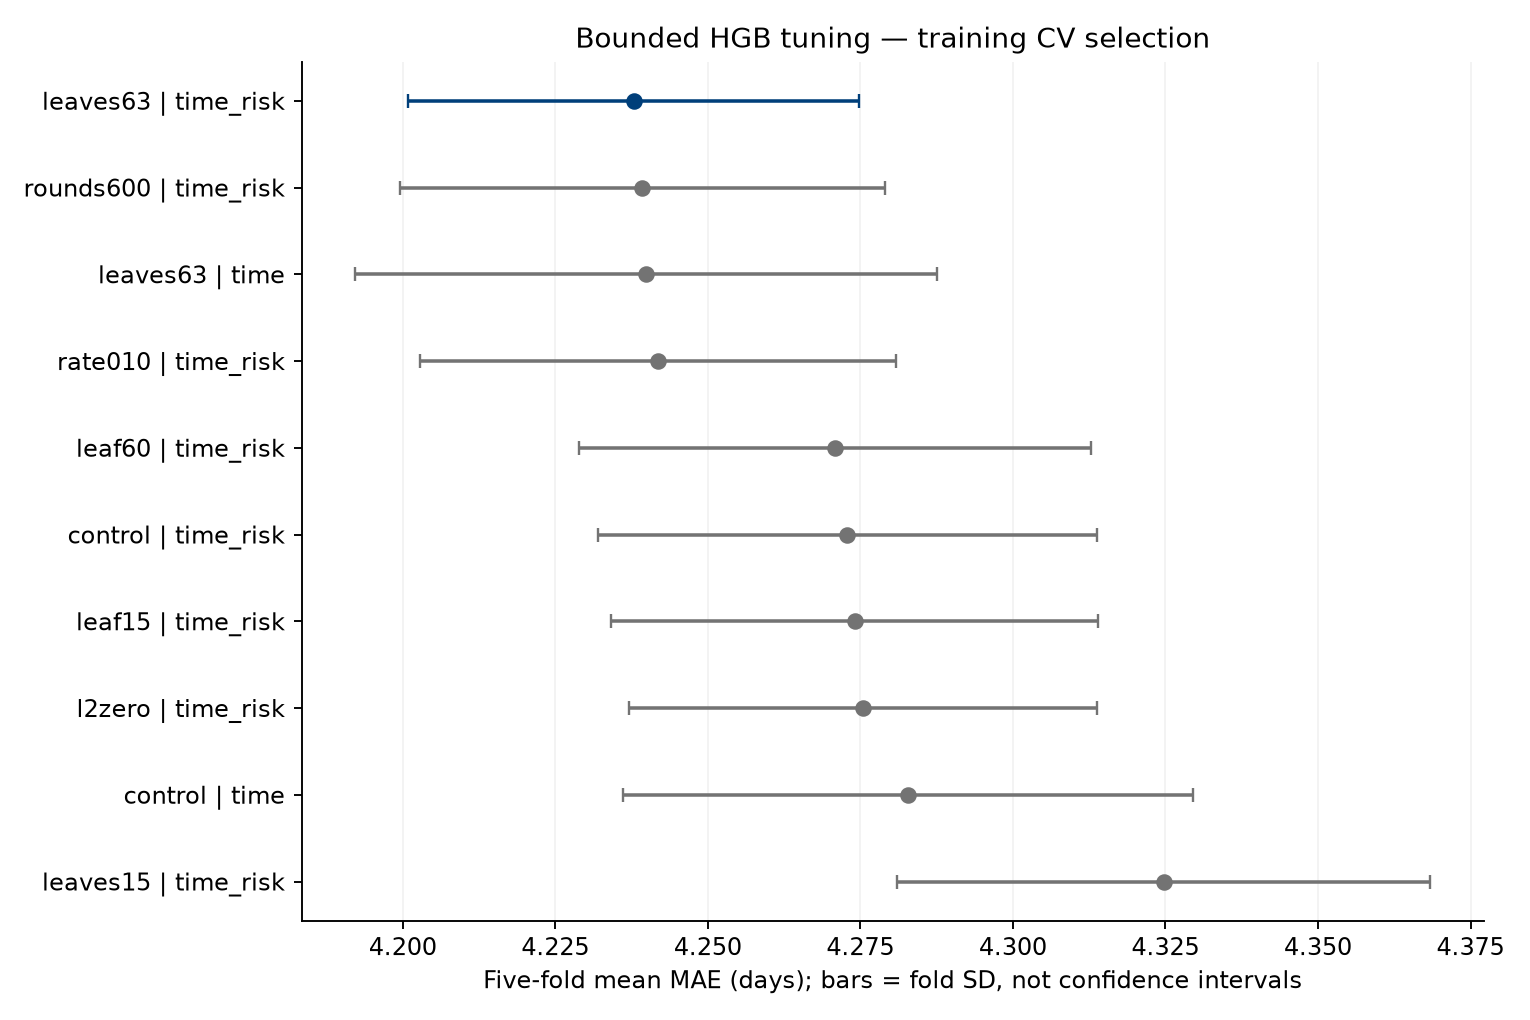

In [9]:
tuning_columns = ["candidate", "CV_MAE", "max_iter", "learning_rate",
                  "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]
display(parameter_results[tuning_columns].sort_values("CV_MAE").round(4))
selected = json.loads((ROOT / "config/selected_model.json").read_text())
assert parameter_results.loc[parameter_results.CV_MAE.idxmin(), "candidate"] == selected["candidate"]
display(Image(filename=str(ROOT / "results/figures/cv_parameter_comparison.png")))

**Finding.** Increasing the maximum leaf count from **31 to 63** reduces CV MAE from **4.2729 to 4.2378 days**. The chosen setting uses absolute-error loss, **300 iterations**, learning rate **0.05**, minimum leaf size **30**, L2 regularisation **10**, no early stopping and seed **33**. Increasing rounds or learning rate also helps relative to the control, but does not beat the selected setting on mean CV MAE.

**Selection decision.** Retain the 63-leaf time/risk model. Its gain is small and it is the best of the settings evaluated, not a global optimum. The tuning table's `fit_MAE` is mean fitting error within the outer folds, not the final full-training score reported later. Earlier development had already exposed these folds and test orders; this search is further development evidence.

## 6. Does combining models add useful improvement?

Stacking is tested because models from different families may make complementary errors. An equal average is a simple combination reference. The MAE-weighted combination learns non-negative weights summing to one from out-of-fold base predictions; it cannot rely on fitting-set predictions as if they were unseen observations.

In the latest experiment, Ridge and random forest are tuned with **three inner folds** inside each of the **five outer training folds**. HGB is held at its selected setting, with its risk construction rebuilt within the appropriate training boundaries. Outer-validation labels do not fit the corresponding combination. The fold-tuned Ridge/RF configurations differ from the fixed variants in Section 4, so their results are listed separately. This experiment supplies outer CV evidence only, with no final full-training stack or test score.

In [10]:
stack = pd.read_csv(TABLES / "stacking_outer_cv_comparison.csv")
stack["CV SD"] = stack.fold_MAE_SD_days * np.sqrt(4 / 5)  # convert sample to population SD
stack_view = stack[["label", "mean_fold_MAE_days", "CV SD"]].rename(columns={
    "label": "Model", "mean_fold_MAE_days": "CV MAE"})
display(stack_view.round(6))

weights = pd.read_csv(TABLES / "stacking_fold_weights.csv")
selected_weights = weights.loc[weights.model.eq("stack_three_tuned")]
display(selected_weights.groupby("base_model").weight.agg(["min", "max"]).round(4))

,Model,CV MAE,CV SD
0,Fixed Ridge,5.035208,0.033141
1,Fixed random forest,4.806196,0.046242
2,Published HGB,4.237815,0.033004
3,Tuned Ridge,4.921914,0.032571
4,Tuned random forest,4.600224,0.038985
5,Fixed Ridge + forest: mean,4.841101,0.040423
6,Fixed Ridge + forest: MAE stack,4.799663,0.044658
7,Fixed Ridge + forest + HGB: mean,4.542078,0.037727
8,Fixed Ridge + forest + HGB: MAE stack,4.237815,0.033004
9,Tuned Ridge + forest: mean,4.663172,0.034305


,min,max
base_model,,
forest_tuned,0.0063,0.0244
hgb,0.9756,0.9937
ridge_tuned,0.0000,0.0000


**Finding.** Equal averaging of tuned Ridge, random forest and HGB gives CV MAE **4.4441 days**, worse than HGB alone. The learned three-model combination reaches **4.2374**, compared with HGB's **4.2378**: a reduction of **0.000419 days**, about **36 seconds** of mean absolute error.

The weights explain the limited gain. HGB receives **97.6%–99.4%** across folds, Ridge receives zero, and random forest supplies only a small correction. Combining different model names is insufficient when the extra models provide little complementary signal.

**Retention decision.** Keep single HGB for the final Train–CV–Test evaluation. The latest stack adds complexity for negligible improvement, and has no final test evaluation to report. HGB was previously selected using these outer folds, so this comparison is not independent nested validation of the entire development history.

## 7. Evaluate the retained model

### 7.1 Train–CV–Test on the same orders

The table below reports all fixed configurations on the same training population, CV folds and **31,836 test orders**. Training error measures fit to the fitting design, including cross-fitted risk where used. CV measures held-out error during development; test scores compare the frozen choices on the common holdout. Their differences help assess how much of a training improvement carries over to unseen rows.

RMSE and R² supplement MAE. R² compares squared error with variation around the test mean; **0.3675 is not 36.75% accuracy**. The latest fold-tuned stacking procedures have no final Train/Test scores and are therefore not inserted into this table.

,Model,Train MAE,CV MAE,CV SD,Test MAE,Test RMSE,Test R²
0,Delivery promise,12.7308,12.7308,0.0508,12.7219,15.0933,-1.5854
1,Training mean,6.4437,6.4439,0.0304,6.3743,9.3872,-0.0001
2,Training median,6.1478,6.1480,0.0373,6.0752,9.6616,-0.0594
3,OLS baseline,5.0045,5.0196,0.0379,4.9607,7.8947,0.2926
4,Single-tree baseline,4.9751,5.0585,0.0476,5.0297,8.0311,0.2680
5,Ridge F1,4.9724,4.9836,0.0369,4.9214,7.8537,0.3000
6,RF F1,3.8850,4.7269,0.0476,4.6525,7.5879,0.3466
7,RF log-target F1,3.7645,4.5386,0.0441,4.4542,7.7209,0.3234
8,OLS + time/risk,4.7550,4.7741,0.0416,4.6983,7.5970,0.3450
9,Single tree + time/risk,4.6530,4.7615,0.0373,4.6783,7.6125,0.3423


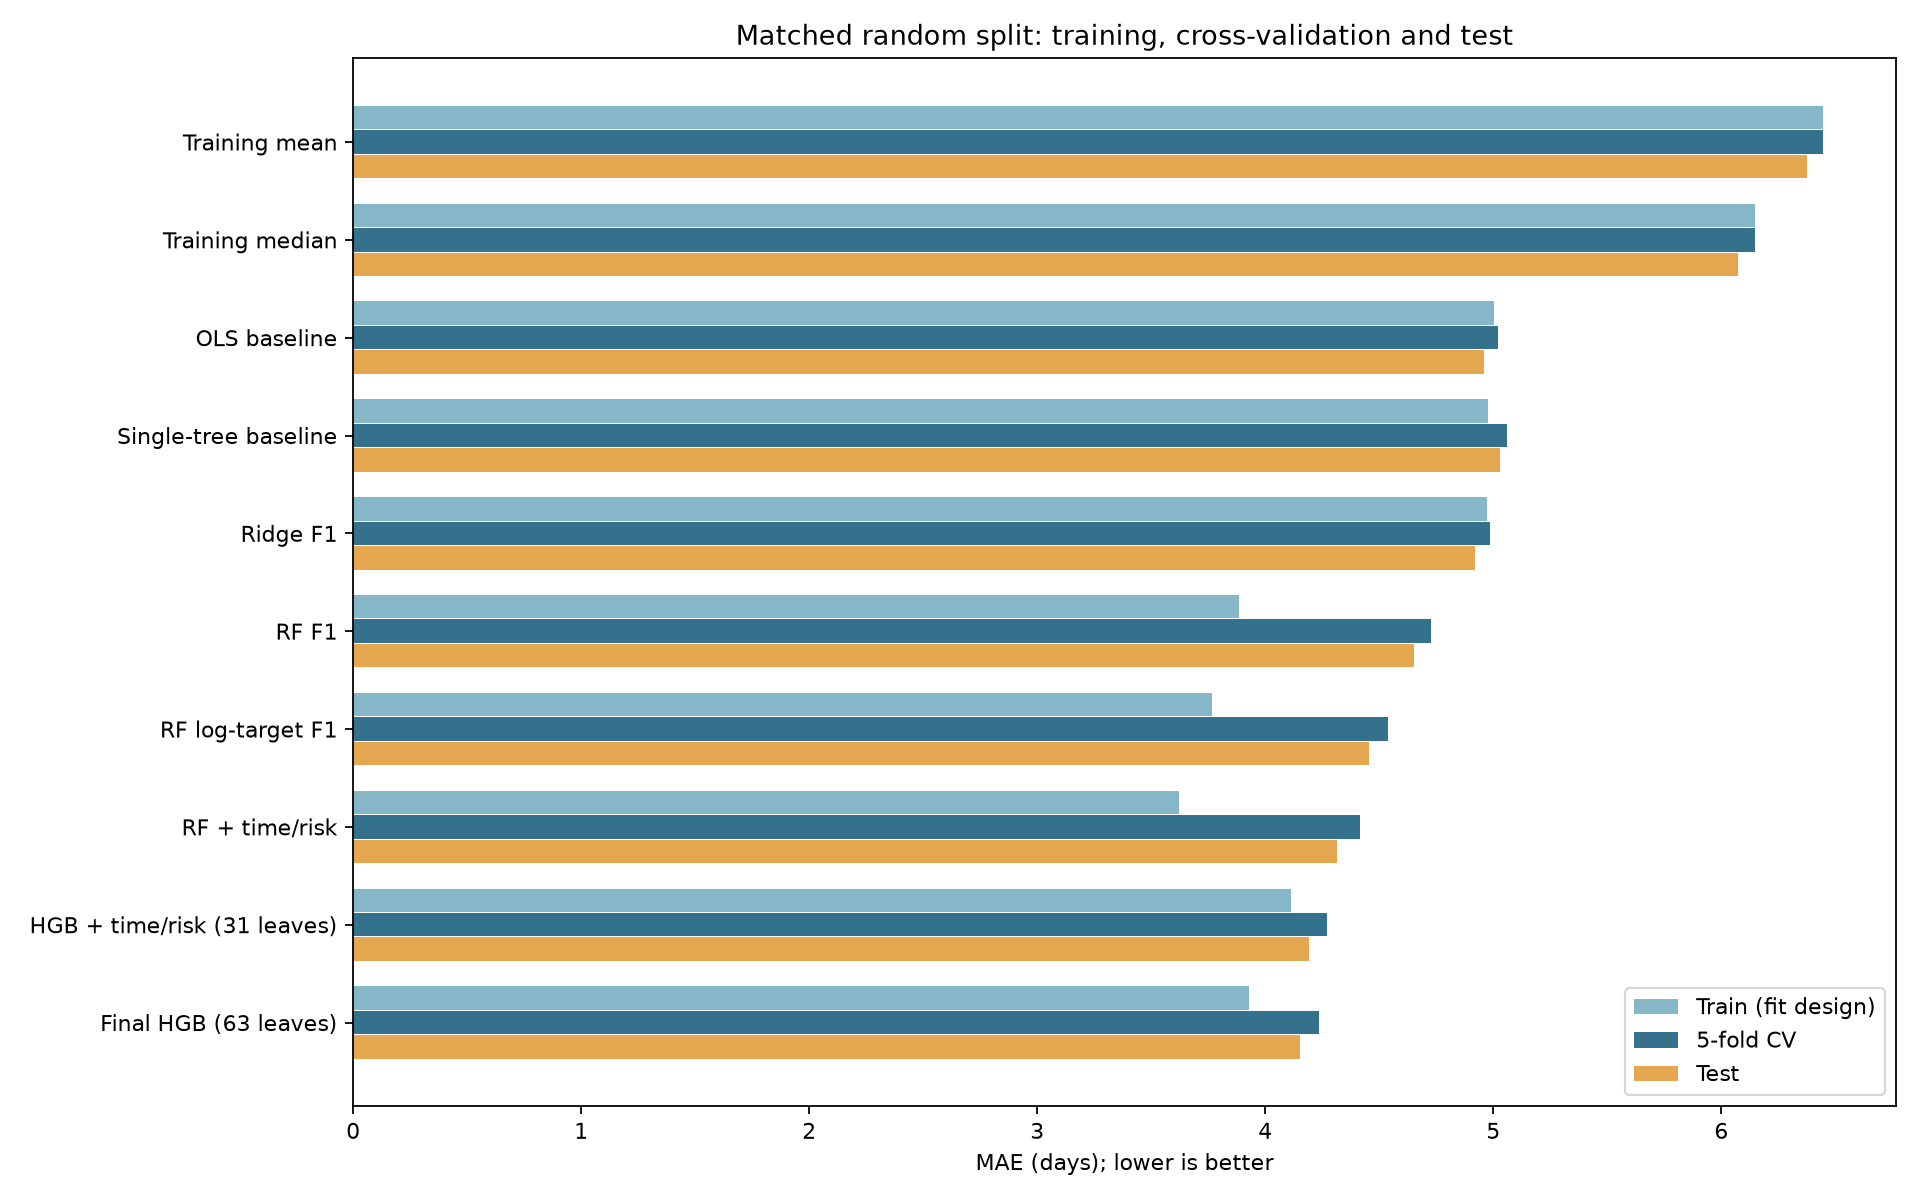

In [11]:
display(model_scores(comparison.model.tolist(), include_test=True))
final = comparison.set_index("model").loc["Final HGB (63 leaves)"]
np.testing.assert_allclose(final.Test_MAE_days, 4.150491686642425, atol=1e-12, rtol=0)
display(Image(filename=str(RESULTS / "figures/train_cv_test_comparison.png")))

**Finding.** Final HGB has **Train MAE 3.9295**, **CV MAE 4.2378** and **Test MAE 4.1505 days**. Test RMSE is **7.4651 days**, R² **0.3675**, and **56.93%** of predictions lie within three days of the observed duration. CV and test errors are similar, while training error is lower; the model fits training data better without a large additional test-error jump under this random protocol.

Test MAE is **16.33% lower than OLS**, **17.48% lower than the single tree** and **31.68% lower than the training-median reference**. These comparisons include model and feature changes. The final leaf-count change alone improves test MAE by about **1.00%**, from 4.1923 to 4.1505 days.

**Interpretation.** The retained model is useful relative to the specified references, but a four-day average error is still material for arrival communication. RMSE being much larger than MAE indicates a minority of large misses. The next breakdown checks where those misses occur rather than treating the overall average as sufficient evidence.

### 7.2 Which deliveries are still difficult?

Residuals are **predicted minus observed duration**: negative bias indicates underprediction. Actual-duration groups are diagnostic slices defined after receipt, never features available at purchase. Route groups use the all-sellers/any-seller rule; they provide a second partition of the same test set, so their counts or errors must not be added to the duration partition.

Alongside per-order error, the contribution table weights each group's MAE by its order count to calculate its share of total absolute error. Squared-error shares similarly use `n × RMSE²`. This separates severe errors in a small group from a large group's contribution to the overall score.

,dimension,group,n,MAE_days,RMSE_days,R2,bias_days,within_3_days_pct
0,actual duration,0–7 days,8584,2.2940,3.1264,-2.9917,1.9441,72.2973
1,actual duration,7–14 days,13334,2.6044,3.5298,-2.0406,0.6293,67.7366
2,actual duration,14–30 days,8454,5.3738,6.7497,-1.6526,-4.1787,33.7473
3,actual duration,30–60 days,1365,18.8525,20.7559,-7.9130,-18.8266,2.4908
4,actual duration,>60 days,99,66.1881,74.5964,-4.4852,-66.1881,0.0000
5,route,All sellers same-state,11431,2.9544,5.7292,0.2210,-1.0426,69.9676
6,route,Any seller cross-state,20405,4.8205,8.2800,0.2842,-1.4987,49.6300


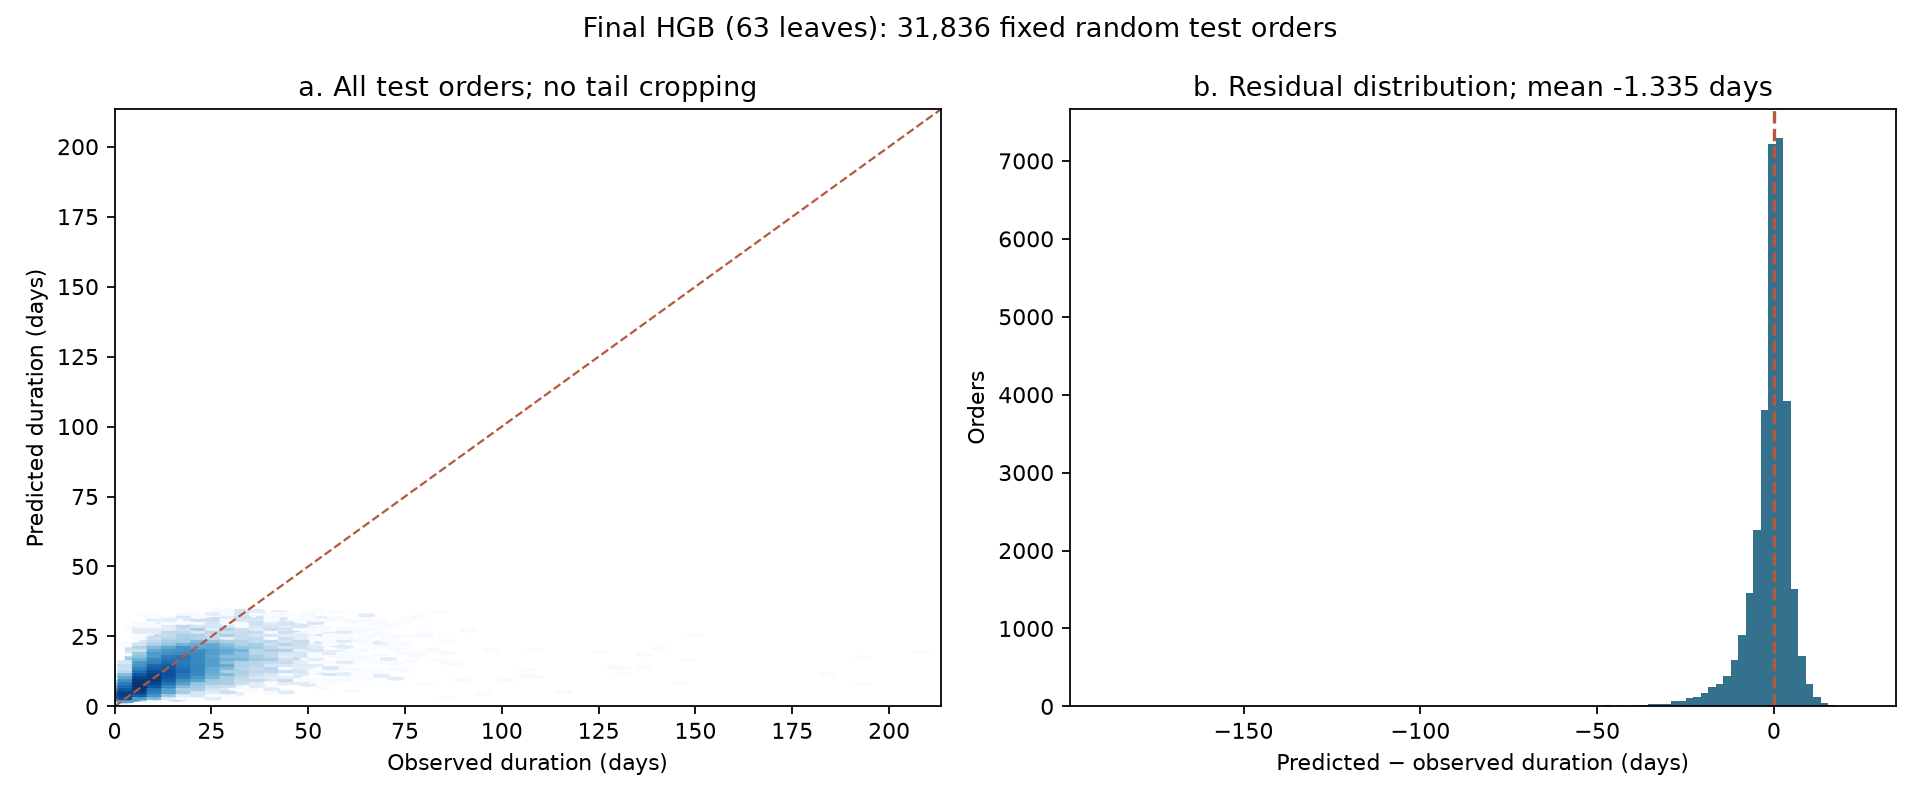

In [12]:
error_groups = pd.read_csv(TABLES / "hgb_test_error_groups.csv")
display(error_groups.round(4))
display(Image(filename=str(RESULTS / "figures/hgb_test_errors.png")))

In [13]:
duration_errors = error_groups.loc[error_groups.dimension.eq("actual duration")].copy()
# A group's mean error must be weighted by its size to obtain its total contribution.
duration_errors["order_share_pct"] = 100 * duration_errors.n / 31836
absolute_total = 31836 * final.Test_MAE_days
squared_total = 31836 * final.Test_RMSE_days ** 2
duration_errors["absolute_error_share_pct"] = 100 * duration_errors.n * duration_errors.MAE_days / absolute_total
duration_errors["squared_error_share_pct"] = 100 * duration_errors.n * duration_errors.RMSE_days ** 2 / squared_total
np.testing.assert_allclose(duration_errors.absolute_error_share_pct.sum(), 100, atol=1e-8)
np.testing.assert_allclose(duration_errors.squared_error_share_pct.sum(), 100, atol=1e-8)
display(duration_errors[["group", "n", "order_share_pct", "absolute_error_share_pct",
                         "squared_error_share_pct"]].round(2))

,group,n,order_share_pct,absolute_error_share_pct,squared_error_share_pct
0,0–7 days,8584,26.96,14.90,4.73
1,7–14 days,13334,41.88,26.28,9.36
2,14–30 days,8454,26.55,34.38,21.71
3,30–60 days,1365,4.29,19.48,33.15
4,>60 days,99,0.31,4.96,31.05


**Finding.** For 0–7-day and 7–14-day orders, MAE is **2.2940** and **2.6044 days**. Error increases to **5.3738 days** at 14–30 days, **18.8525** at 30–60 days (n=1,365), and **66.1881** above 60 days (n=99). Bias in the slowest groups is almost as negative as MAE, showing systematic underprediction rather than balanced over- and underestimates. Overall signed bias is **−1.3349 days**.

Orders above 30 days account for **4.60%** of test rows and **24.43%** of absolute error, but **64.20%** of squared error. The >60-day group alone contributes **4.96%** of absolute error. Thus the tail is particularly important for RMSE and service risk, while it does not explain all of the overall MAE: the much larger 14–30-day group contributes **34.38%** of absolute error.

Cross-state MAE is **4.8205 days**, compared with **2.9544** for same-state orders. This is consistent with more difficult geographic routes, but the unadjusted comparison does not identify a causal state-border effect. Purchase information can distinguish broad risk patterns; it cannot directly observe later carrier delays or operational incidents.

### 7.3 Timestamp sensitivity

Some orders have receipt earlier than another recorded event despite a valid non-negative purchase-to-receipt target. The archive cannot resolve which event timestamp is wrong. The **84** such orders are flagged and retained: **59 training / 25 test**. The check below removes flagged test rows at evaluation only, using the same fitted model.

In [14]:
sensitivity = pd.read_csv(TABLES / "chronology_evaluation_sensitivity.csv")
display(sensitivity[["evaluation_cohort", "n", "MAE_days", "RMSE_days", "bias_days"]].round(4))

,evaluation_cohort,n,MAE_days,RMSE_days,bias_days
0,All fixed test orders,31836,4.1505,7.4651,-1.3349
1,Excluding chronology flags at evaluation only,31811,4.1523,7.4676,-1.3367
2,Chronology-flagged test orders only,25,1.8897,2.6785,0.9468


**Finding.** Removing 25 flagged test orders changes MAE from **4.1505 to 4.1523 days**, leaving 31,811 rows. These flags do not explain the overall error magnitude. This is not a test of retraining without the 59 training flags, nor proof that the remaining timestamps are error-free.

## 8. Which input groups does the final model rely on?

HGB does not provide linear coefficients. We use **grouped permutation importance**: shuffle related raw fields together, recompute their derived features and auxiliary risk, and measure how much MAE increases for the frozen model. This tests predictive reliance on an input group, including its path through derived features, without fitting the model again.

The evaluation uses a fixed **8,000-test-order subset**, seed 33, with **five shuffles per group**. Its baseline MAE is **4.1280 days**, different from the complete test-set MAE. Importance is measured in added error days, so groups can be compared on the same scale. The reported SD describes variability across shuffles, not a confidence interval for deployment performance.

,group,MAE_increase_mean_days,MAE_increase_SD_days
0,Geography and route,1.3504,0.0328
1,Purchase date and calendar,0.9771,0.0212
2,Quoted promise,0.5302,0.0155
3,Seller identity and composition,0.1026,0.0082
4,Price and freight,0.0451,0.0069
5,Product category and composition,0.0310,0.0048
6,Product weight and volume,0.0266,0.0051


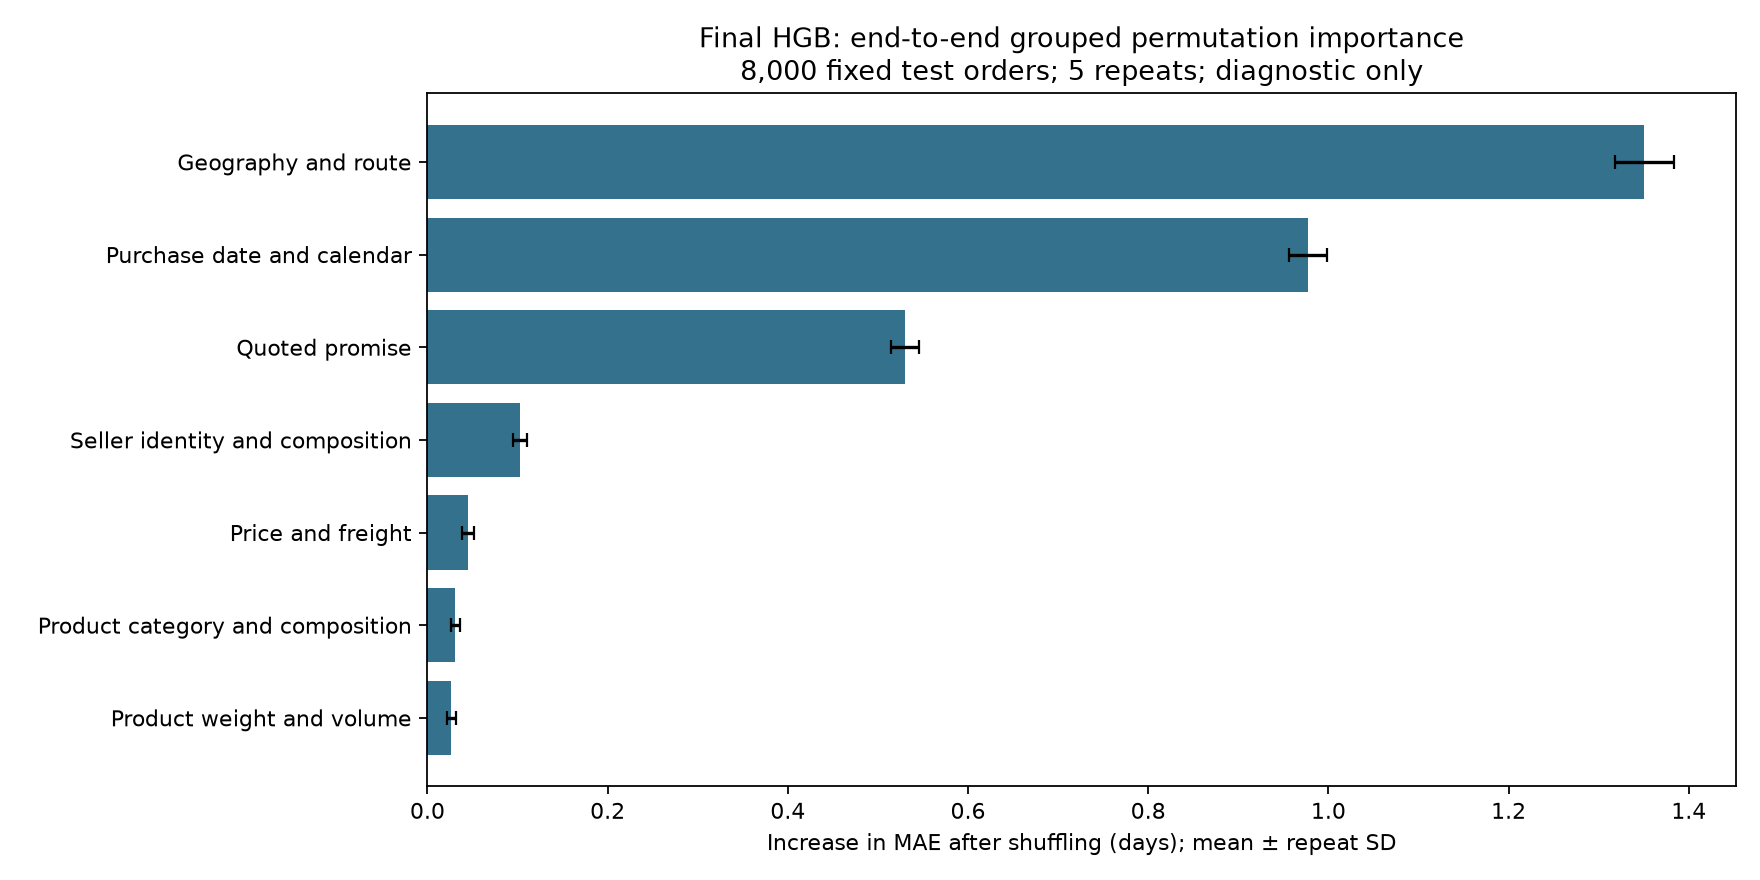

In [15]:
importance = pd.read_csv(TABLES / "hgb_grouped_permutation_importance.csv")
display(importance[["group", "MAE_increase_mean_days", "MAE_increase_SD_days"]].round(4))
display(Image(filename=str(RESULTS / "figures/hgb_grouped_permutation_importance.png")))
finish(context, final)

**Finding.** Shuffling geography/routes increases MAE by **1.3504 days**, purchase date/calendar by **0.9771**, and quoted promise by **0.5302**. These are the strongest group-level dependencies. Seller identity/composition adds **0.1026 days** of shuffled error; price/freight, category/composition and weight/volume each add less than 0.05 days.

**Interpretation.** The Phase 1 geographic and promise associations remain useful after joint modelling, and the temporal signal helps distinguish periods within this historical sample. A smaller permutation increment does not show that a feature is useless: other correlated inputs may substitute for it. Shuffled combinations can also be unrealistic. These increments are neither causal effects nor additive percentages of total error.

## 9. Implications and limitations

**Retained approach.** Start with OLS and a bounded single tree, compare regularised and ensemble variants, then retain the expanded-purchase/time/risk HGB with 63 leaves. The common evaluation shows improvement over both fitted baselines and the fixed/statistical references. Latest stacking adds too little to justify retaining a separate final combination.

**Business use.** Customer-service and fulfilment teams could use the estimate to support arrival-expectation communication and identify orders needing human follow-up. It is a point estimate, not a guaranteed date or a tested intervention. No effect on satisfaction, logistics cost or operational decisions has been measured.

**Coverage and remaining error.** The target is observed completed delivery, so cancellations and unresolved orders are outside the evaluated population. Long deliveries remain substantially underestimated. An apparently short prediction does not establish that an order is safe from delay, and the auxiliary risk feature has only a small marginal regression benefit.

**Evaluation limits.** Random splitting includes the same historical periods and recurring sellers/routes on both sides; it does not test future periods or unseen entities. Archived input availability remains an assumption. CV and test data were exposed during earlier development, so the results are retrospective development comparisons rather than fresh external confirmation. Different rows use different input representations, and the parameter search is bounded.

## Takeaways

Delivery-duration regression is supported by measurable purchase-time signal and improves on the specified references. The main useful additions are more detailed purchase information and time representation; tuning adds a smaller gain. Retain single HGB, report both overall and duration/route errors, and preserve the long-tail and completed-delivery limits when describing its use.

### Sources and AI disclosure

- [Phase 1 delivery-regression notebook](https://github.com/IT5006-Group9/IT5006-Group9-Olist-Project/blob/main/notebooks/phase1/03_delivery_lead_time_regression_eda.ipynb), cells 1–3, 17, 20–26 and 29–35: question, target, EDA signal, promise reference and initial evaluation proposal.
- [Official IT5006 project brief](https://prakashsukhwal.github.io/IT5006/IT5006_Project_Description_2026Aug_V2.html); course Olist starter cells 19–21 and Great Expectations lab cells 18–23: schema, joins and data-contract practice, adapted to this order-level task.
- Zaghloul et al. (2024), DOI **10.1016/j.jretconser.2024.103865**, §3.3 supplies the 67/33 ratio; split seed and CV folds are project adaptations. Literature and report-ready evidence are recorded in the [report evidence guide](../docs/report_evidence_guide.md).
- Implementations and frozen specifications: `src/` and `config/`; [reproduction instructions](../README.md), [course alignment](../docs/notebook_alignment.md), detailed [tuning](best_scheme_review.ipynb), [report evidence](report_supplement_review.ipynb) and [stacking](tuned_stacking_comparison.ipynb) notebooks.
- **AI assistance:** AI assisted code and explanatory text. The notebook was executed and key data/metric calculations checked against saved fitted experiments. This statement does not assert human approval or final submission.